# Customer Segmentation Project (a1-g02)

This notebook performs customer segmentation using RFM Analysis and K-Means Clustering on transactional data.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Load and Clean Dataset
Loading transaction dataset from local relative path and performing basic data cleaning operations.

In [17]:
# Read directly from the same folder (relative path)
file_path = "retail_transactions_segmentation.csv"

df = pd.read_csv(file_path)

df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

df = df.dropna()
df = df.drop_duplicates()
df = df[df["amount"] > 0]

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (3663, 4)
   customer_id transaction_date  amount product_category
0         5206       2024-01-31  162.65          Fashion
1         5153       2024-07-03  389.85          Fashion
2         5102       2024-11-13  453.72    Home & Living
3         5073       2024-03-11  824.74      Electronics
4         5097       2024-12-28  181.74           Sports


## 2. Build RFM Features
Calculating Recency, Frequency, and Monetary metrics for each customer.

In [18]:
reference_date = df["transaction_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    Recency=("transaction_date", lambda x: (reference_date - x.max()).days),
    Frequency=("customer_id", "count"),
    Monetary=("amount", "sum")
)

print("RFM Table Head:")
print(rfm.head())
print("\nTotal customers analyzed:", len(rfm))

RFM Table Head:
             Recency  Frequency  Monetary
customer_id                              
5001               2         16   5172.45
5002              23         18   6158.98
5003              37          3    654.12
5004               5         35  31050.88
5005              26         16   5700.91

Total customers analyzed: 300


## 3. Scale Features and Select Optimal K
Scaling RFM features with StandardScaler and evaluating optimal number of clusters using Elbow Method & Silhouette Scores.

Best K based on silhouette score: 2
Best silhouette score: 0.6789


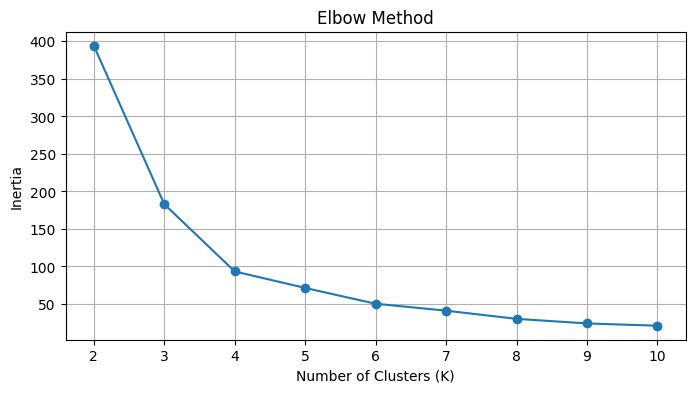

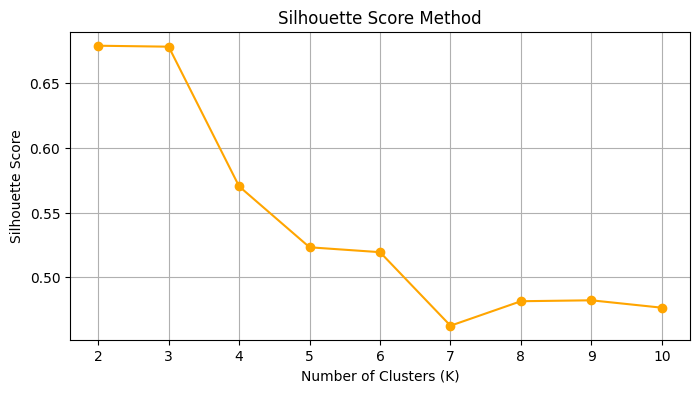

In [19]:
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

best_k_silhouette = k_values[np.argmax(silhouette_scores)]
FINAL_K = best_k_silhouette

print("Best K based on silhouette score:", FINAL_K)
print("Best silhouette score:", round(max(silhouette_scores), 4))

# Elbow Plot
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# Silhouette Plot
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker="o", color="orange")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Method")
plt.grid(True)
plt.show()

## 4. Apply K-Means Clustering
Fitting K-Means algorithm using optimal K and assigning cluster labels to customers.

In [20]:
kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm["Cluster"].value_counts().sort_index())

Cluster Distribution:
Cluster
0     40
1    260
Name: count, dtype: int64


## 5. PCA Visualization
Dimensionality reduction using PCA to visualize cluster separation in 2D space.

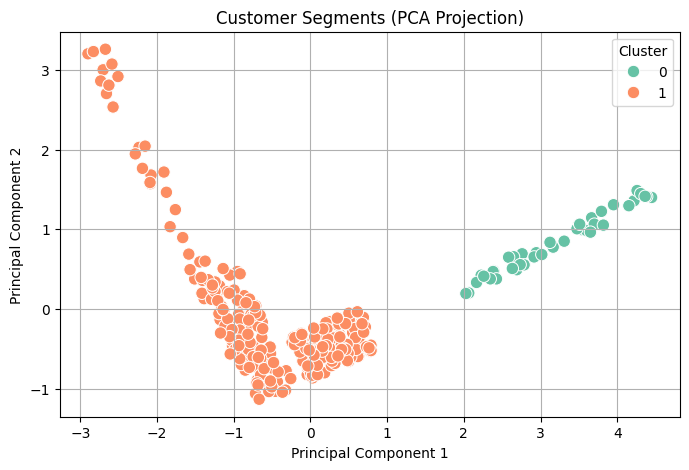

In [21]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PC1"] = rfm_pca[:, 0]
rfm["PC2"] = rfm_pca[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

## 6. Cluster Profiling, Personas, and Business Strategies
Analyzing segment mean averages to derive customer personas and actionable business strategies.

In [22]:
cluster_means = rfm.groupby("Cluster")[features].mean().round(2)
cluster_means["Customer_Count"] = rfm["Cluster"].value_counts().sort_index()

# Dynamically select VIP cluster based on maximum monetary value
vip_cluster = cluster_means["Monetary"].idxmax()

personas = {}
strategies = {}

recency_median = rfm["Recency"].median()
frequency_median = rfm["Frequency"].median()

for cluster_id, row in cluster_means.iterrows():
    if cluster_id == vip_cluster:
        personas[cluster_id] = "VIP / Champions"
        strategies[cluster_id] = (
            "Highest spending and purchase frequency. "
            "Action: Premium rewards, early product access, and priority support."
        )
    elif FINAL_K == 2:
        personas[cluster_id] = "Standard / Mainstream Customers"
        strategies[cluster_id] = (
            "Core customer base with moderate spending and average order frequency. "
            "Action: Targeted engagement, cross-selling, and promotional offers."
        )
    elif row["Recency"] <= recency_median and row["Frequency"] >= frequency_median:
        personas[cluster_id] = "Loyal Customers"
        strategies[cluster_id] = "Loyalty rewards, personalized offers, and cross-selling."
    elif row["Recency"] > recency_median:
        personas[cluster_id] = "At-Risk Customers"
        strategies[cluster_id] = "Re-engagement campaigns, special discounts, and reminders."
    elif row["Frequency"] < frequency_median:
        personas[cluster_id] = "Occasional Customers"
        strategies[cluster_id] = "Targeted promotions to increase purchase frequency."
    else:
        personas[cluster_id] = "Regular Customers"
        strategies[cluster_id] = "Personalized recommendations and retention campaigns."

cluster_means["Persona"] = cluster_means.index.map(personas)
cluster_means["Business Strategy"] = cluster_means.index.map(strategies)

display_cols = ["Customer_Count", "Recency", "Frequency", "Monetary", "Persona", "Business Strategy"]
print("Final Segment Summary:")
print(cluster_means[display_cols])

Final Segment Summary:
         Customer_Count  Recency  Frequency  Monetary  \
Cluster                                                 
0                    40     8.40       35.0  29683.61   
1                   260    61.78        8.7   2661.07   

                                 Persona  \
Cluster                                    
0                        VIP / Champions   
1        Standard / Mainstream Customers   

                                         Business Strategy  
Cluster                                                     
0        Highest spending and purchase frequency. Actio...  
1        Core customer base with moderate spending and ...  
